In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import squarify
from pandas.plotting import parallel_coordinates
import math
import seaborn as sns
import scipy
import plotly

In [2]:
dataset = pd.read_csv('menu.csv')

In [3]:
dataset.head()

,Category,Item,Serving Size,Calories,Calories from Fat,Total Fat,Total Fat (% Daily Value),Saturated Fat,Saturated Fat (% Daily Value),Trans Fat,...,Carbohydrates,Carbohydrates (% Daily Value),Dietary Fiber,Dietary Fiber (% Daily Value),Sugars,Protein,Vitamin A (% Daily Value),Vitamin C (% Daily Value),Calcium (% Daily Value),Iron (% Daily Value)
0,Breakfast,Egg McMuffin,4.8 oz (136 g),300,120,13.0,20,5.0,25,0.0,...,31,10,4,17,3,17,10,0,25,15
1,Breakfast,Egg White Delight,4.8 oz (135 g),250,70,8.0,12,3.0,15,0.0,...,30,10,4,17,3,18,6,0,25,8
2,Breakfast,Sausage McMuffin,3.9 oz (111 g),370,200,23.0,35,8.0,42,0.0,...,29,10,4,17,2,14,8,0,25,10
3,Breakfast,Sausage McMuffin with Egg,5.7 oz (161 g),450,250,28.0,43,10.0,52,0.0,...,30,10,4,17,2,21,15,0,30,15
4,Breakfast,Sausage McMuffin with Egg Whites,5.7 oz (161 g),400,210,23.0,35,8.0,42,0.0,...,30,10,4,17,2,21,6,0,25,10


In [4]:
dataset.drop(['Total Fat (% Daily Value)','Saturated Fat','Saturated Fat (% Daily Value)',
              'Cholesterol (% Daily Value)', 'Sodium', 'Sodium (% Daily Value)', 
              'Carbohydrates (% Daily Value)', 'Dietary Fiber', 'Dietary Fiber (% Daily Value)',
             'Calcium (% Daily Value)'], axis=1, inplace=True)

In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Category                   260 non-null    object 
 1   Item                       260 non-null    object 
 2   Serving Size               260 non-null    object 
 3   Calories                   260 non-null    int64  
 4   Calories from Fat          260 non-null    int64  
 5   Total Fat                  260 non-null    float64
 6   Trans Fat                  260 non-null    float64
 7   Cholesterol                260 non-null    int64  
 8   Carbohydrates              260 non-null    int64  
 9   Sugars                     260 non-null    int64  
 10  Protein                    260 non-null    int64  
 11  Vitamin A (% Daily Value)  260 non-null    int64  
 12  Vitamin C (% Daily Value)  260 non-null    int64  
 13  Iron (% Daily Value)       260 non-null    int64  

In [6]:
dataset.isna().sum()

Category                     0
Item                         0
Serving Size                 0
Calories                     0
Calories from Fat            0
Total Fat                    0
Trans Fat                    0
Cholesterol                  0
Carbohydrates                0
Sugars                       0
Protein                      0
Vitamin A (% Daily Value)    0
Vitamin C (% Daily Value)    0
Iron (% Daily Value)         0
dtype: int64

In [7]:
dataset.duplicated().sum()

0

In [8]:
dataset.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Category                   260 non-null    object 
 1   Item                       260 non-null    object 
 2   Serving Size               260 non-null    object 
 3   Calories                   260 non-null    int64  
 4   Calories from Fat          260 non-null    int64  
 5   Total Fat                  260 non-null    float64
 6   Trans Fat                  260 non-null    float64
 7   Cholesterol                260 non-null    int64  
 8   Carbohydrates              260 non-null    int64  
 9   Sugars                     260 non-null    int64  
 10  Protein                    260 non-null    int64  
 11  Vitamin A (% Daily Value)  260 non-null    int64  
 12  Vitamin C (% Daily Value)  260 non-null    int64  
 13  Iron (% Daily Value)       260 non-null    int64  

In [9]:
copied_ds = dataset.copy()

for col in dataset.select_dtypes(include=['object']).columns:
    copied_ds[col] = copied_ds[col].astype('string')
for col in dataset.select_dtypes(include=['float64']).columns:
    copied_ds[col] = copied_ds[col].astype('float16')
for col in dataset.select_dtypes(include=['int64']).columns:
    copied_ds[col] = copied_ds[col].astype('int16')

dataset = copied_ds

In [10]:
dataset.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Category                   260 non-null    string 
 1   Item                       260 non-null    string 
 2   Serving Size               260 non-null    string 
 3   Calories                   260 non-null    int16  
 4   Calories from Fat          260 non-null    int16  
 5   Total Fat                  260 non-null    float16
 6   Trans Fat                  260 non-null    float16
 7   Cholesterol                260 non-null    int16  
 8   Carbohydrates              260 non-null    int16  
 9   Sugars                     260 non-null    int16  
 10  Protein                    260 non-null    int16  
 11  Vitamin A (% Daily Value)  260 non-null    int16  
 12  Vitamin C (% Daily Value)  260 non-null    int16  
 13  Iron (% Daily Value)       260 non-null    int16  

In [11]:
vitA=pd.DataFrame(dataset.groupby('Category')['Vitamin A (% Daily Value)'].mean())
vitC=pd.DataFrame(dataset.groupby('Category')['Vitamin C (% Daily Value)'].mean())

In [12]:
vitA


,Vitamin A (% Daily Value)
Category,
Beef & Pork,6.933333
Beverages,0.740741
Breakfast,6.928571
Chicken & Fish,20.444444
Coffee & Tea,10.736842
Desserts,5.142857
Salads,146.666667
Smoothies & Shakes,18.750000
Snacks & Sides,4.846154


In [13]:
vitC

,Vitamin C (% Daily Value)
Category,
Beef & Pork,7.333333
Beverages,23.481481
Breakfast,8.904762
Chicken & Fish,12.629630
Coffee & Tea,0.000000
Desserts,4.142857
Salads,28.333333
Smoothies & Shakes,6.964286
Snacks & Sides,28.153846


In [14]:
vits=vitA.merge(vitC, left_on='Category', right_on='Category',
          suffixes=('_left', '_right'))

In [15]:
vits

,Vitamin A (% Daily Value),Vitamin C (% Daily Value)
Category,,
Beef & Pork,6.933333,7.333333
Beverages,0.740741,23.481481
Breakfast,6.928571,8.904762
Chicken & Fish,20.444444,12.629630
Coffee & Tea,10.736842,0.000000
Desserts,5.142857,4.142857
Salads,146.666667,28.333333
Smoothies & Shakes,18.750000,6.964286
Snacks & Sides,4.846154,28.153846


In [16]:
d = {'Category': ['Beef & Pork', 'Beverages', 'Breakfast', 'Chicken & Fish', 'Coffee & Tea', 'Desserts', 'Salads',
                  'Smoothies & Shakes', 'Snacks & Sides'], 'Category': ['Beef & Pork', 'Beverages', 'Breakfast',
                                                                        'Chicken & Fish', 'Coffee & Tea', 'Desserts', 'Salads',
                  'Smoothies & Shakes', 'Snacks & Sides']}
df = pd.DataFrame(data=d)
df

,Category
0,Beef & Pork
1,Beverages
2,Breakfast
3,Chicken & Fish
4,Coffee & Tea
5,Desserts
6,Salads
7,Smoothies & Shakes
8,Snacks & Sides


In [17]:
vits = vits.merge(df, left_on='Category', right_on='Category',
          suffixes=('_left', '_right'))

In [18]:
vits

,Category,Vitamin A (% Daily Value),Vitamin C (% Daily Value)
0,Beef & Pork,6.933333,7.333333
1,Beverages,0.740741,23.481481
2,Breakfast,6.928571,8.904762
3,Chicken & Fish,20.444444,12.629630
4,Coffee & Tea,10.736842,0.000000
5,Desserts,5.142857,4.142857
6,Salads,146.666667,28.333333
7,Smoothies & Shakes,18.750000,6.964286
8,Snacks & Sides,4.846154,28.153846


In [19]:
sug=pd.DataFrame(dataset.groupby('Category')['Sugars'].mean())
carb=pd.DataFrame(dataset.groupby('Category')['Carbohydrates'].mean())

In [20]:
merged=carb.merge(sug, left_on='Category', right_on='Category',
          suffixes=('_left', '_right'))

In [21]:
d = {'Category': ['Beef & Pork', 'Beverages', 'Breakfast', 'Chicken & Fish', 'Coffee & Tea', 'Desserts', 'Salads',
                  'Smoothies & Shakes', 'Snacks & Sides'], 'Category': ['Beef & Pork', 'Beverages', 'Breakfast',
                                                                        'Chicken & Fish', 'Coffee & Tea', 'Desserts', 'Salads',
                  'Smoothies & Shakes', 'Snacks & Sides']}
df = pd.DataFrame(data=d)

In [22]:
merged= merged.merge(df, left_on='Category', right_on='Category',
          suffixes=('_left', '_right'))
merged

,Category,Carbohydrates,Sugars
0,Beef & Pork,40.133333,8.800000
1,Beverages,28.814815,27.851852
2,Breakfast,49.761905,8.261905
3,Chicken & Fish,49.074074,7.333333
4,Coffee & Tea,44.526316,39.610526
5,Desserts,34.857143,26.142857
6,Salads,21.666667,6.833333
7,Smoothies & Shakes,90.428571,77.892857
8,Snacks & Sides,29.153846,4.076923


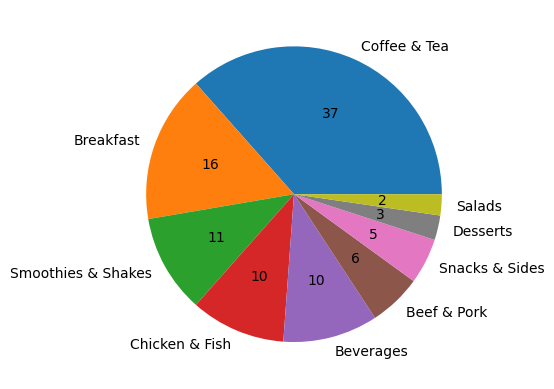

In [23]:
types = dataset['Category'].value_counts()
types = pd.DataFrame({'Category':types.index, 'Count':types.values})
plt.pie(types['Count'], labels=types['Category'], autopct = lambda p: format(p,'.0f') if p > 1 else None)
plt.show()

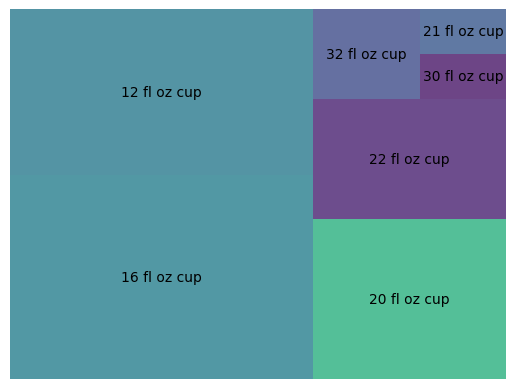

In [24]:
data = dataset.loc[dataset['Category'] == 'Coffee & Tea']
data = data['Serving Size'].value_counts()
squarify.plot(sizes=data.values, label=data.index, alpha=.8 )
plt.axis('off')
plt.show()

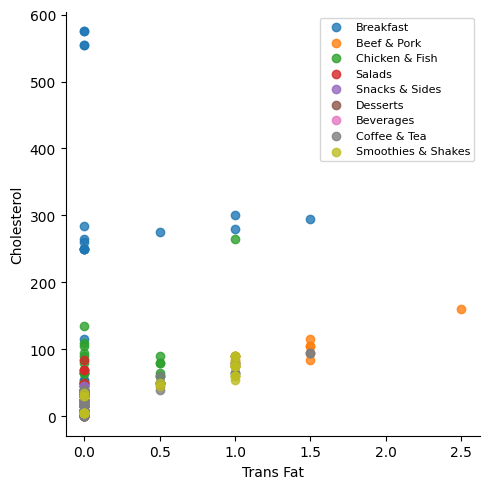

In [25]:
sns.lmplot( x='Trans Fat', y='Cholesterol', data=dataset, fit_reg=False, hue='Category', legend=False)
 
# Move the legend to an empty part of the plot
plt.legend(loc='upper right', fontsize=8)

plt.show()


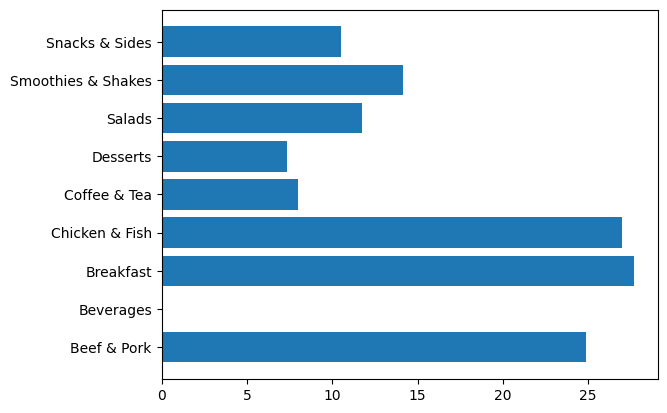

In [26]:
height = dataset.groupby('Category')['Total Fat'].mean()
bars = ('Beef & Pork', 'Beverages', 'Breakfast', 'Chicken & Fish', 'Coffee & Tea', 'Desserts',
        'Salads', 'Smoothies & Shakes', 'Snacks & Sides')

y_pos = np.arange(len(bars))

# Create bars
plt.barh(y_pos, height)

# Create names on the x-axis
plt.yticks(y_pos, bars)

# Show graphic
plt.show()

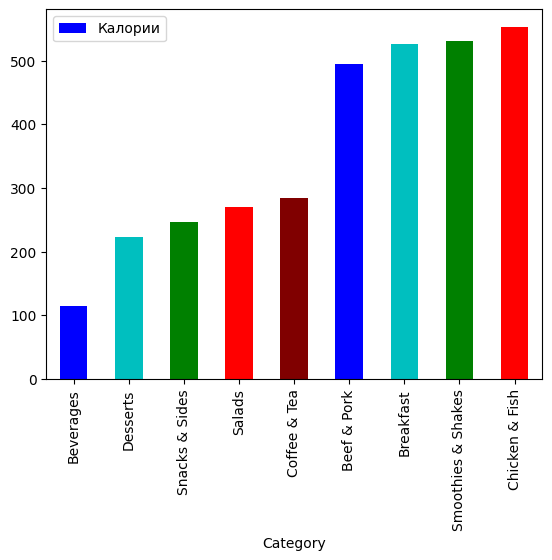

In [27]:
cal = pd.DataFrame(dataset.groupby('Category')['Calories'].mean()).sort_values('Calories')
plot = cal.plot.bar(y='Calories', color=['b','c','g','r','maroon'], label='Калории')

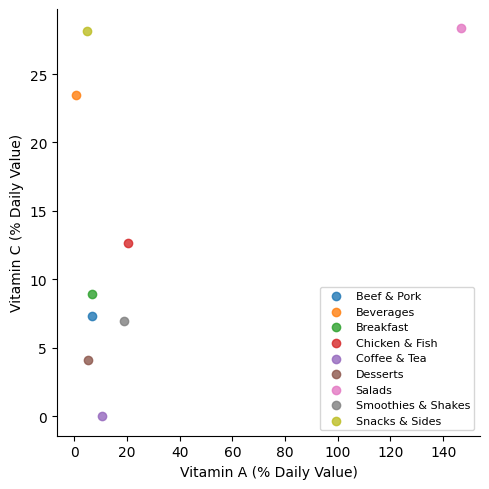

In [28]:
sns.lmplot(x='Vitamin A (% Daily Value)', y='Vitamin C (% Daily Value)', data=vits, fit_reg=False, hue='Category', legend=False)
 
# Move the legend to an empty part of the plot
plt.legend(loc='lower right', fontsize=8)

plt.show()


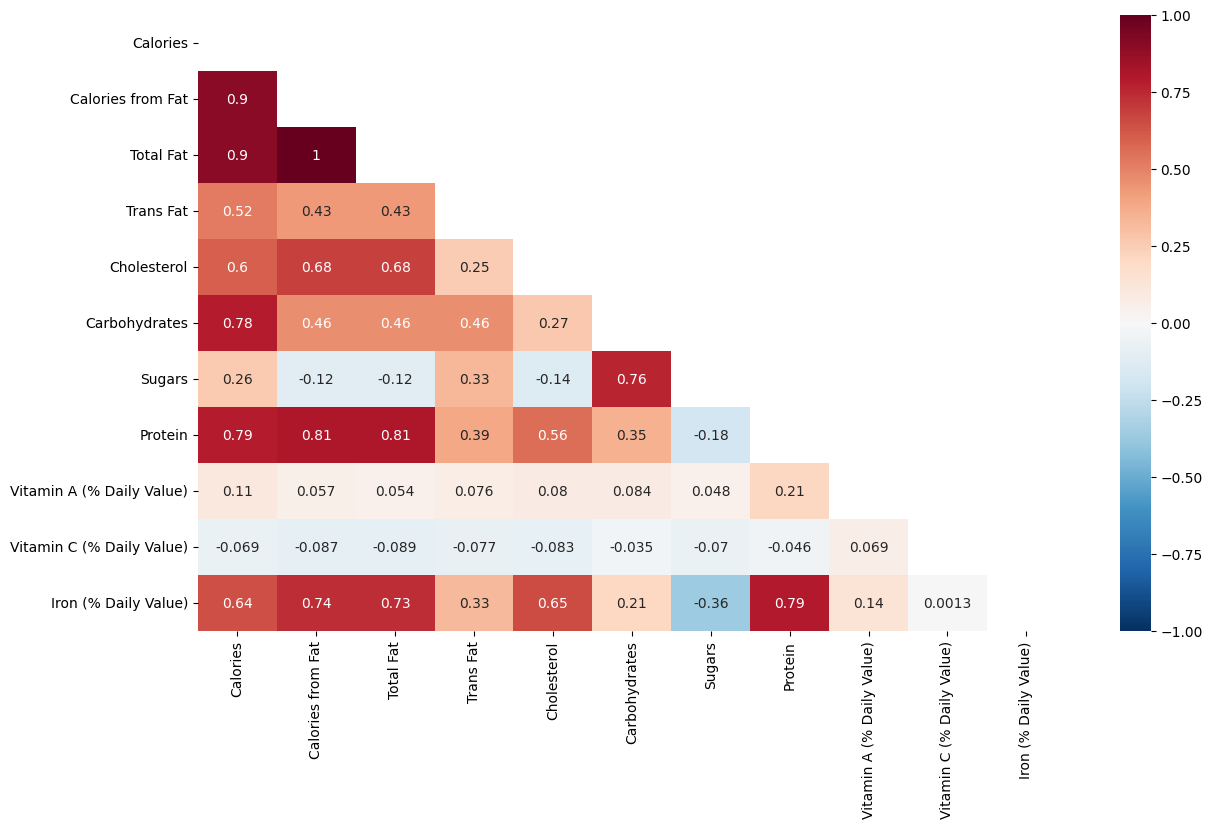

In [29]:
plt.figure(figsize = (14,8))

m =np.triu(np.ones_like(dataset.corr(), dtype=bool))

sns.heatmap(dataset.corr(), mask = m, annot = True, vmin= -1.0, vmax= 1.0, center = 0, cmap = 'RdBu_r');


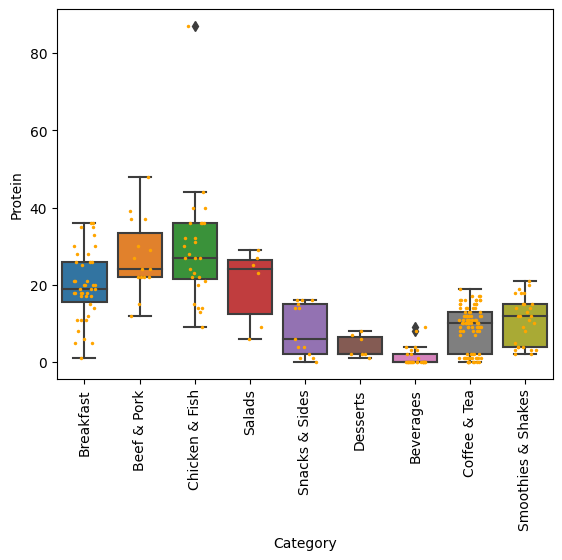

In [30]:
sns.boxplot(x='Category', y='Protein', data=dataset)
ax = sns.stripplot(x='Category', y='Protein', data=dataset, color="orange", jitter=0.2, size=2.5)
plt.xticks(rotation=90)
plt.show()

In [31]:
sorted_df = dataset.sort_values('Protein', ascending=False)
sorted_df

,Category,Item,Serving Size,Calories,Calories from Fat,Total Fat,Trans Fat,Cholesterol,Carbohydrates,Sugars,Protein,Vitamin A (% Daily Value),Vitamin C (% Daily Value),Iron (% Daily Value)
82,Chicken & Fish,Chicken McNuggets (40 piece),22.8 oz (646 g),1880,1060,118.0,1.0,265,118,1,87,0,15,25
47,Beef & Pork,Double Quarter Pounder with Cheese,10 oz (283 g),750,380,43.0,2.5,160,42,10,48,10,2,35
81,Chicken & Fish,Chicken McNuggets (20 piece),11.4 oz (323 g),940,530,59.0,0.0,135,59,0,44,0,8,10
60,Chicken & Fish,Premium Grilled Chicken Club Sandwich,8.3 oz (235 g),510,180,20.0,0.0,105,44,9,40,8,20,20
64,Chicken & Fish,Bacon Clubhouse Grilled Chicken Sandwich,9.5 oz (270 g),590,230,25.0,0.0,110,51,14,40,8,30,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110,Beverages,Coca-Cola Classic (Small),16 fl oz cup,140,0,0.0,0.0,0,39,39,0,0,0,0
136,Beverages,Dasani Water Bottle,16.9 fl oz,0,0,0.0,0.0,0,0,0,0,0,0,0
127,Beverages,Sprite (Medium),21 fl oz cup,200,0,0.0,0.0,0,54,54,0,0,0,0
138,Coffee & Tea,Iced Tea (Medium),21 fl oz cup,0,0,0.0,0.0,0,0,0,0,0,0,0


In [32]:
#sns.pairplot(dataset)
#plt.show()

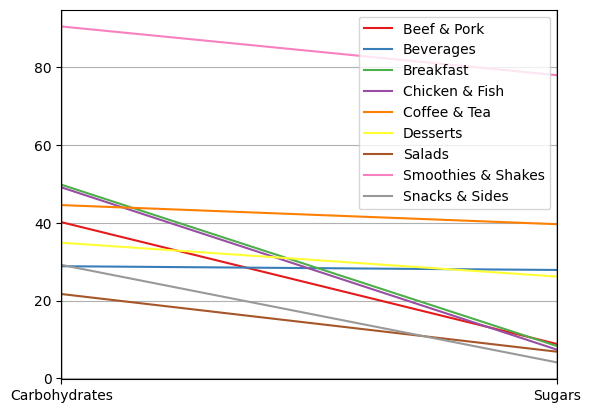

In [33]:
parallel_coordinates(merged, 'Category', colormap=plt.get_cmap("Set1"))
#plt.xticks(rotation=90)
plt.show()


In [34]:
iron=pd.DataFrame(dataset.groupby('Category')['Iron (% Daily Value)'].mean())


In [35]:
d = {'Category': ['Beef & Pork', 'Beverages', 'Breakfast', 'Chicken & Fish', 'Coffee & Tea', 'Desserts', 'Salads',
                  'Smoothies & Shakes', 'Snacks & Sides'], 'Category': ['Beef & Pork', 'Beverages', 'Breakfast',
                                                                        'Chicken & Fish', 'Coffee & Tea', 'Desserts', 'Salads',
                  'Smoothies & Shakes', 'Snacks & Sides']}
df = pd.DataFrame(data=d)

In [36]:
iron = iron.merge(df, left_on='Category', right_on='Category',
          suffixes=('_left', '_right'))

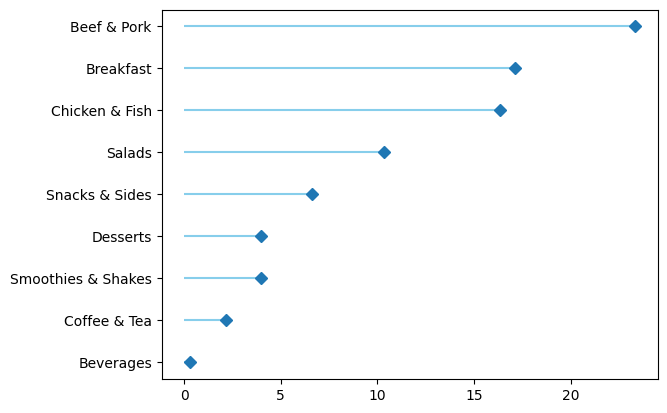

In [37]:
ordered_df = iron.sort_values(by='Iron (% Daily Value)')
my_range=range(1,len(iron.index)+1)
 
plt.hlines(y=my_range, xmin=0, xmax=ordered_df['Iron (% Daily Value)'], color='skyblue')
plt.plot(ordered_df['Iron (% Daily Value)'], my_range, "D")
plt.yticks(my_range, ordered_df['Category'])
plt.show()

In [38]:
iron

,Category,Iron (% Daily Value)
0,Beef & Pork,23.333333
1,Beverages,0.296296
2,Breakfast,17.142857
3,Chicken & Fish,16.370370
4,Coffee & Tea,2.147368
5,Desserts,4.000000
6,Salads,10.333333
7,Smoothies & Shakes,3.964286
8,Snacks & Sides,6.615385
